<a href="https://colab.research.google.com/github/choROPeNt/segment-anything-2/blob/dev/notebooks/promotion/CNN_deghostnig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeGhost-UNet



Panoramic microscopy images generated using the Olympus Stream software may exhibit stitching artifacts when adjacent tiles are imperfectly aligned. These artifacts, commonly referred to as ghost artifacts, occur when overlapping regions of neighboring images are slightly mismatched and blended together. As a result, structural features—such as fiber edges in composite micrographs—appear duplicated, blurred, or spatially shifted.

This effect can be described mathematically as a linear superposition of the original image and a shifted version of itself:
$$
I_{\text{ghost}} = (1 - \alpha)\, I + \alpha\, \text{shift}(I),
$$
where:
- $I$ denotes the clean image,
- $\text{shift}(I)$ represents a spatially shifted copy,
- $\alpha \in [0,1]$ controls the blending strength.

In this formulation, ghosting is not a blur in the classical sense, but rather a structured misalignment artifact resulting from image blending.

---

Residual Learning for Deghosting

Reconstructing the clean image directly from $I_{\text{ghost}}$ is possible but suboptimal from a learning perspective. Instead, we reformulate the problem in terms of residual prediction.

From the forward model, the clean image can be written as:
$$
I = I_{\text{ghost}} + r,
$$
where the residual is
$$
r = I - I_{\text{ghost}}.
$$
Substituting the ghost model yields:
$$
r = \alpha \left(I - \text{shift}(I)\right).
$$
This shows that the residual is a structured, spatially correlated signal that encodes the difference between aligned and misaligned content.

Learning this residual directly offers several advantages:
- Reduced output magnitude: The residual is typically much smaller than the image intensity range, making optimization more stable.
- Identity-safe behavior: If no artifact is present, the optimal residual is zero.
- Faster convergence: The network focuses on modeling only the artifact component rather than reconstructing the full image.
- Sharper reconstruction: Since the underlying image is already sharp, subtracting the structured residual restores edges without requiring explicit gradient constraints.

Therefore, the DeGhost-UNet architecture is designed to predict the residual r, and the final reconstruction is obtained via:
$$
\hat{I}_{\text{clean}} = I_{\text{ghost}} + r_\theta,
$$
where r_\theta is the network prediction.

This residual formulation aligns naturally with the physics of stitching artifacts and results in improved stability, faster convergence, and better preservation of fine fiber structures compared to direct image-to-image mapping.

In [3]:
using_colab = True
if using_colab:
  !pip install torchinfo
  from google.colab import drive
  drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from __future__ import annotations
from pathlib import Path
from typing import Optional, Tuple, Dict

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import random

import matplotlib.pyplot as plt

from torchinfo import summary

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)

print("Using device:", device)

Using device: cuda


In [5]:
# ----------------------------
# Ghosting augmentation
# ----------------------------
def add_ghost_shadow_safe(
    clean: torch.Tensor,
    alpha: Optional[float] = None,
    dy: Optional[int] = None,
    dx: Optional[int] = None,
    max_shift: int = 1,
    allow_diagonal: bool = True,
    blur_sigma: float = 0.0,
    noise_std: float = 0.0,
    crop_safe: bool = True,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[torch.Tensor, torch.Tensor, Dict]:
    """
    clean: (H,W) or (1,H,W) float in [0,1]
    returns: ghost, clean, meta (both possibly center-cropped by max_shift)
    """
    if rng is None:
        rng = np.random.default_rng()

    if clean.ndim == 2:
        clean = clean.unsqueeze(0)

    # choose random shift if not given
    if dy is None or dx is None:
        base = [(1,0),(-1,0),(0,1),(0,-1)]
        if allow_diagonal:
            base += [(1,1),(1,-1),(-1,1),(-1,-1)]
        dy0, dx0 = base[int(rng.integers(0, len(base)))]
        s = 1 if max_shift <= 1 else int(rng.integers(1, max_shift + 1))
        dy, dx = dy0 * s, dx0 * s

    if alpha is None:
        alpha = float(rng.uniform(0.25, 0.75))

    shifted = torch.roll(clean, shifts=(int(dy), int(dx)), dims=(-2, -1))

    # optional blur on shifted copy only (torch-only approx)
    if blur_sigma > 0:
        # simple separable-ish blur via avgpool as a cheap proxy (fast for testing)
        # replace with torchvision.gaussian_blur if you want exact gaussian
        k = max(3, int(round(blur_sigma * 6)) | 1)
        pad = k // 2
        shifted = F.avg_pool2d(shifted.unsqueeze(0), kernel_size=k, stride=1, padding=pad).squeeze(0)

    ghost = (1.0 - float(alpha)) * clean + float(alpha) * shifted

    if noise_std > 0:
        ghost = ghost + torch.randn_like(ghost) * float(noise_std)

    ghost = ghost.clamp(0, 1)

    # safe crop to remove wrap-around from roll
    if crop_safe and max_shift > 0:
        _, H, W = ghost.shape
        m = int(max_shift)
        if H <= 2*m or W <= 2*m:
            raise ValueError(f"crop_safe too large: max_shift={m} for patch {H}x{W}")
        ghost = ghost[:, m:H-m, m:W-m]
        clean = clean[:, m:H-m, m:W-m]

    meta = {
        "alpha": float(alpha),
        "dy": int(dy),
        "dx": int(dx),
        "cropped_by": int(max_shift if crop_safe else 0),
    }
    return ghost, clean, meta


def random_crop_pair(img1: torch.Tensor, img2: torch.Tensor, crop_size: int, rng: np.random.Generator):
    """
    Random crop same region from img1 and img2.
    Both must be (1,H,W).
    """
    _, H, W = img1.shape
    if H < crop_size or W < crop_size:
        raise ValueError(f"Crop size {crop_size} larger than image {H}x{W}.")

    top  = int(rng.integers(0, H - crop_size + 1))
    left = int(rng.integers(0, W - crop_size + 1))

    img1 = img1[:, top:top+crop_size, left:left+crop_size]
    img2 = img2[:, top:top+crop_size, left:left+crop_size]
    return img1, img2


def downscale_by2_pair(a: torch.Tensor, b: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """
    a,b: (1,H,W) float
    returns (1,H/2,W/2) using area resampling (best for microscopy)
    """
    a4 = a.unsqueeze(0)  # (1,1,H,W)
    b4 = b.unsqueeze(0)
    a_ds = F.interpolate(a4, scale_factor=0.5, mode="area").squeeze(0)
    b_ds = F.interpolate(b4, scale_factor=0.5, mode="area").squeeze(0)
    return a_ds, b_ds


# ----------------------------
# Dataset
# ----------------------------
class PatchNPYDataset(Dataset):
    """
    Loads pre-extracted patches from a .npy/.npz and applies ghosting transform.
    Returns:
      ghost: (1,h,w) float32 in [0,1]
      clean: (1,h,w) float32 in [0,1]
      meta: dict of tensors (alpha,dx,dy,cropped_by)
    """
    def __init__(
        self,
        patches_path: str | Path,
        normalize: str = "uint8",
        max_shift: int = 8,
        allow_diagonal: bool = True,
        alpha_range: Tuple[float, float] = (0.6, 0.9),
        blur_sigma_range: Tuple[float, float] = (0.0, 0.0),
        noise_std_range: Tuple[float, float] = (0.0, 0.0),
        crop_safe: bool = True,
        random_flip_rot: bool = True,
        crop_size: Optional[int] = 256,
        downscale_factor2: bool = True,     # <--- requested
        seed: int = 0,
    ):
        self.patches_path = Path(patches_path)
        if not self.patches_path.exists():
            raise FileNotFoundError(self.patches_path)

        arr = np.load(self.patches_path, allow_pickle=False)
        if isinstance(arr, np.lib.npyio.NpzFile):
            key = list(arr.keys())[0]
            arr = arr[key]

        if arr.ndim == 4 and arr.shape[-1] == 1:
            arr = arr[..., 0]
        if arr.ndim != 3:
            raise ValueError(f"Expected (N,H,W) or (N,H,W,1), got {arr.shape}")

        self.patches = arr
        self.normalize = normalize

        self.max_shift = int(max_shift)
        self.allow_diagonal = allow_diagonal
        self.alpha_range = alpha_range
        self.blur_sigma_range = blur_sigma_range
        self.noise_std_range = noise_std_range
        self.crop_safe = crop_safe

        self.random_flip_rot = random_flip_rot
        self.crop_size = crop_size
        self.downscale_factor2 = downscale_factor2

        self.seed = int(seed)

        # shift directions
        self.base_dirs = [(1,0),(-1,0),(0,1),(0,-1)]
        if self.allow_diagonal:
            self.base_dirs += [(1,1),(1,-1),(-1,1),(-1,-1)]

    def __len__(self) -> int:
        return self.patches.shape[0]

    def _to_tensor01(self, x_np: np.ndarray) -> torch.Tensor:
        x = torch.from_numpy(x_np)
        if x.ndim != 2:
            raise ValueError("Patch must be 2D after loading.")
        x = x.to(torch.float32)

        if self.normalize == "uint8":
            x = x / 255.0
        elif self.normalize == "none":
            pass
        else:
            raise ValueError(f"Unknown normalize='{self.normalize}'")

        return x.clamp(0, 1)

    def _augment_geom(self, x: torch.Tensor, rng: np.random.Generator) -> torch.Tensor:
        # x: (H,W)
        if not self.random_flip_rot:
            return x
        k = int(rng.integers(0, 4))
        x = torch.rot90(x, k, dims=(0, 1))
        if rng.random() < 0.5:
            x = torch.flip(x, dims=(1,))
        if rng.random() < 0.5:
            x = torch.flip(x, dims=(0,))
        return x

    def __getitem__(self, idx: int):
        # per-sample RNG (safe with multi-workers)
        rng = np.random.default_rng(self.seed + idx)

        clean = self._to_tensor01(self.patches[idx])
        clean = self._augment_geom(clean, rng)          # (H,W)
        clean = clean.unsqueeze(0)                      # (1,H,W)



        # sample ghost params
        alpha = float(rng.uniform(*self.alpha_range))

        dy0, dx0 = self.base_dirs[int(rng.integers(0, len(self.base_dirs)))]
        s = 1 if self.max_shift <= 1 else int(rng.integers(1, self.max_shift + 1))
        dy, dx = int(dy0 * s), int(dx0 * s)

        blur_sigma = float(rng.uniform(*self.blur_sigma_range))
        noise_std  = float(rng.uniform(*self.noise_std_range))

        ghost, clean_out, meta = add_ghost_shadow_safe(
            clean,
            alpha=alpha,
            dy=dy, dx=dx,
            max_shift=self.max_shift,
            allow_diagonal=self.allow_diagonal,
            blur_sigma=blur_sigma,
            noise_std=noise_std,
            crop_safe=self.crop_safe,
            rng=rng,
        )

        # random crop (after safe-crop)
        if self.crop_size is not None:
            ghost, clean_out = random_crop_pair(ghost, clean_out, crop_size=self.crop_size, rng=rng)
        # downscale AFTER cropping (for test training)
        if self.downscale_factor2:
            ghost, clean_out = downscale_by2_pair(ghost, clean_out)

            # also scale shift meta to the new pixel grid (optional, but correct)
            meta["dx"] = int(round(meta["dx"] / 2))
            meta["dy"] = int(round(meta["dy"] / 2))
            meta["cropped_by"] = int(round(meta["cropped_by"] / 2))

        # meta -> tensors so default collate works nicely
        meta_t = {
            "alpha": torch.tensor(meta["alpha"], dtype=torch.float32),
            "dy": torch.tensor(meta["dy"], dtype=torch.float32),
            "dx": torch.tensor(meta["dx"], dtype=torch.float32),
            "cropped_by": torch.tensor(meta["cropped_by"], dtype=torch.int64),
        }

        return ghost.to(torch.float32), clean_out.to(torch.float32), meta_t


# ----------------------------
# Dataloader helper
# ----------------------------
def make_dataloader(
    patches_path: str | Path,
    batch_size: int = 8,
    num_workers: int = 0,
    shuffle: bool = True,
    pin_memory: bool = False,
    persistent_workers: bool = True,
    **dataset_kwargs,
) -> DataLoader:
    ds = PatchNPYDataset(patches_path, **dataset_kwargs)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(persistent_workers and num_workers > 0),
        drop_last=True,
    )

In [23]:
def _safe_groups(c: int, max_groups: int) -> int:
    g = min(max_groups, c)
    while g > 1 and (c % g) != 0:
        g -= 1
    return max(g, 1)


class ResBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int, k: int = 3, max_groups: int = 8):
        super().__init__()
        p = k // 2
        g = _safe_groups(c_out, max_groups)

        self.conv1 = nn.Conv2d(c_in, c_out, k, padding=p)
        self.gn1   = nn.GroupNorm(g, c_out)
        self.act1  = nn.SiLU(inplace=True)

        self.conv2 = nn.Conv2d(c_out, c_out, k, padding=p)
        self.gn2   = nn.GroupNorm(g, c_out)
        self.act2  = nn.SiLU(inplace=True)

        self.skip = nn.Identity() if c_in == c_out else nn.Conv2d(c_in, c_out, 1)

        # start near identity
        nn.init.zeros_(self.conv2.weight)
        if self.conv2.bias is not None:
            nn.init.zeros_(self.conv2.bias)

    def forward(self, x):
        h = self.act1(self.gn1(self.conv1(x)))
        h = self.gn2(self.conv2(h))
        return self.act2(h + self.skip(x))


class Downsample(nn.Module):
    def __init__(self, c_in: int, c_out: int, max_groups: int = 8):
        super().__init__()
        self.conv = nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1)
        g = _safe_groups(c_out, max_groups)
        self.gn  = nn.GroupNorm(g, c_out)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.act(self.gn(self.conv(x)))


class Upsample(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.conv = nn.Conv2d(c_in, c_out, kernel_size=3, padding=1)

    def forward(self, x, size_hw=None):
        x = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=False)
        if size_hw is not None:
            x = F.interpolate(x, size=size_hw, mode="bilinear", align_corners=False)
        return self.conv(x)


class DeGhostUNet(nn.Module):
    """
    Residual U-Net with adjustable levels (downsample steps).

    levels=2 -> bottleneck at H/4
    levels=3 -> bottleneck at H/8 (more context; good for 256 crops)
    """
    def __init__(
        self,
        base: int = 64,
        in_ch: int = 1,
        out_ch: int = 1,
        levels: int = 3,
        max_groups: int = 8,
        mid_blocks: int = 2,
        pad_to_multiple: bool = False,
    ):
        super().__init__()
        assert levels >= 1
        self.levels = levels
        self.pad_to_multiple = pad_to_multiple

        # channel sizes per level: [base, 2base, 4base, ...]
        ch = [base * (2 ** i) for i in range(levels)]

        # Encoder: ResBlock at each level + Downsample between levels
        self.enc_blocks = nn.ModuleList()
        self.downs = nn.ModuleList()

        self.enc_blocks.append(ResBlock(in_ch, ch[0], max_groups=max_groups))
        for i in range(1, levels):
            self.downs.append(Downsample(ch[i - 1], ch[i], max_groups=max_groups))
            self.enc_blocks.append(ResBlock(ch[i], ch[i], max_groups=max_groups))

        # Bottleneck
        mid = []
        for _ in range(mid_blocks):
            mid.append(ResBlock(ch[-1], ch[-1], max_groups=max_groups))
        self.mid = nn.Sequential(*mid)

        # Decoder: Upsample + ResBlock with skip concat
        self.ups = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()

        for i in reversed(range(levels - 1)):
            self.ups.append(Upsample(ch[i + 1], ch[i]))
            self.dec_blocks.append(ResBlock(ch[i] + ch[i], ch[i], max_groups=max_groups))

        self.out = nn.Conv2d(ch[0], out_ch, kernel_size=1)

    def _pad_to(self, x, mult: int):
        B, C, H, W = x.shape
        H2 = ((H + mult - 1) // mult) * mult
        W2 = ((W + mult - 1) // mult) * mult
        pad_h = H2 - H
        pad_w = W2 - W
        x = F.pad(x, (0, pad_w, 0, pad_h), mode="reflect")
        return x, (H, W)

    def forward(self, ghost: torch.Tensor) -> torch.Tensor:
        orig_hw = None
        if self.pad_to_multiple:
            mult = 2 ** self.levels
            ghost, orig_hw = self._pad_to(ghost, mult)

        skips = []

        # level 0
        x = self.enc_blocks[0](ghost)
        skips.append(x)

        # levels 1..L-1
        for i in range(1, self.levels):
            x = self.downs[i - 1](x)
            x = self.enc_blocks[i](x)
            skips.append(x)

        # bottleneck
        x = self.mid(x)

        # decode (levels-1 up steps)
        for k in range(self.levels - 1):
            skip = skips[-2 - k]  # corresponding encoder skip
            x = self.ups[k](x, size_hw=skip.shape[-2:])
            x = self.dec_blocks[k](torch.cat([x, skip], dim=1))

        residual = self.out(x)

        if orig_hw is not None:
            H, W = orig_hw
            residual = residual[..., :H, :W]

        return residual

In [7]:

file_train = Path("/content/drive/MyDrive/Colab Notebooks/DeGhosting/245_004.adj.patches.train.npy")

file_val = Path("/content/drive/MyDrive/Colab Notebooks/DeGhosting/245_004.adj.patches.val.npy")

train_loader = make_dataloader(
        file_train,
        batch_size=16,
        num_workers=0,
        shuffle=True,
        max_shift=12,            # training distribution
        alpha_range=(0.6, 0.9),  # start strong
        crop_size=256,
        downscale_factor2=False,  # <--- fast mode
    )

val_loader = make_dataloader(
    file_val,
    batch_size=16,
    num_workers=0,
    shuffle=False,
    max_shift=12,            # training distribution
    alpha_range=(0.6, 0.9),  # start strong
    crop_size=256,
    downscale_factor2=False,  # <--- fast mode
)

print(f"created data loaders: train size {len(train_loader)}, validation size {len(val_loader)}")

created data loaders: train size 22, validation size 5


In [8]:
ghost, clean, meta = next(iter(train_loader))

print(f"input shape: {ghost.shape}, dtype: {ghost.dtype}, min/max: {ghost.min():.3f}/{ghost.max():.3f}")
print(f"target shape: {clean.shape}, dtype: {clean.dtype}, min/max: {clean.min():.3f}/{clean.max():.3f}")
print(f"meta: {meta}")

input shape: torch.Size([16, 1, 256, 256]), dtype: torch.float32, min/max: 0.206/0.894
target shape: torch.Size([16, 1, 256, 256]), dtype: torch.float32, min/max: 0.184/0.894
meta: {'alpha': tensor([0.8083, 0.7044, 0.6693, 0.6276, 0.8102, 0.8007, 0.7879, 0.6748, 0.7669,
        0.8709, 0.8781, 0.7988, 0.6783, 0.8489, 0.8961, 0.8112]), 'dy': tensor([  0.,   1.,  -8.,   0.,  -6.,  -7.,   0.,  -7., -10.,   3.,   0.,  10.,
          0.,   8.,   3.,  11.]), 'dx': tensor([-12.,   1.,   8.,   5.,   0.,  -7., -11.,   7.,  10.,   0.,  -9.,  10.,
         -3.,  -8.,   3., -11.]), 'cropped_by': tensor([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12])}


## OverFitting Test

In [25]:
# --- Model ---
model = DeGhostUNet(base=64, levels=4, in_ch=1, out_ch=1, pad_to_multiple=True)
summary(model,input_size=(1,1,256,256))

Layer (type:depth-idx)                   Output Shape              Param #
DeGhostUNet                              [1, 1, 256, 256]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─ResBlock: 2-1                     [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                  [1, 64, 256, 256]         640
│    │    └─GroupNorm: 3-2               [1, 64, 256, 256]         128
│    │    └─SiLU: 3-3                    [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                  [1, 64, 256, 256]         36,928
│    │    └─GroupNorm: 3-5               [1, 64, 256, 256]         128
│    │    └─Conv2d: 3-6                  [1, 64, 256, 256]         128
│    │    └─SiLU: 3-7                    [1, 64, 256, 256]         --
├─ModuleList: 1-6                        --                        (recursive)
│    └─Downsample: 2-2                   [1, 128, 128, 128]        --
│    │    └─Conv2d: 3-8                  [1, 128, 128, 128]

In [10]:
model.to(device).train()

ghost, clean, _ = next(iter(train_loader))
ghost, clean = ghost[:,::].to(device), clean[:,::].to(device)

target_res = clean - ghost

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- Overfit one batch ---
for i in range(3000):
    opt.zero_grad()
    pred_res = model(ghost)
    loss = F.l1_loss(pred_res, target_res)
    loss.backward()
    opt.step()

    if i % 50 == 0:
        pred_clean = ghost + pred_res
        rec = F.l1_loss(pred_clean, clean).item()
        print(i, "res_loss", float(loss.detach().cpu()), "rec_loss", rec)

# --- Evaluation ---
model.eval()

with torch.no_grad():
    pred_res = model(ghost)
    pred_clean = (ghost + pred_res).clamp(0, 1)

# --- Baseline identity loss ---
identity_loss = F.l1_loss(ghost, clean).item()
recon_loss = F.l1_loss(pred_clean, clean).item()

print("Identity loss:", identity_loss)
print("Reconstruction loss:", recon_loss)



0 res_loss 0.08435513824224472 rec_loss 0.08435513079166412


KeyboardInterrupt: 

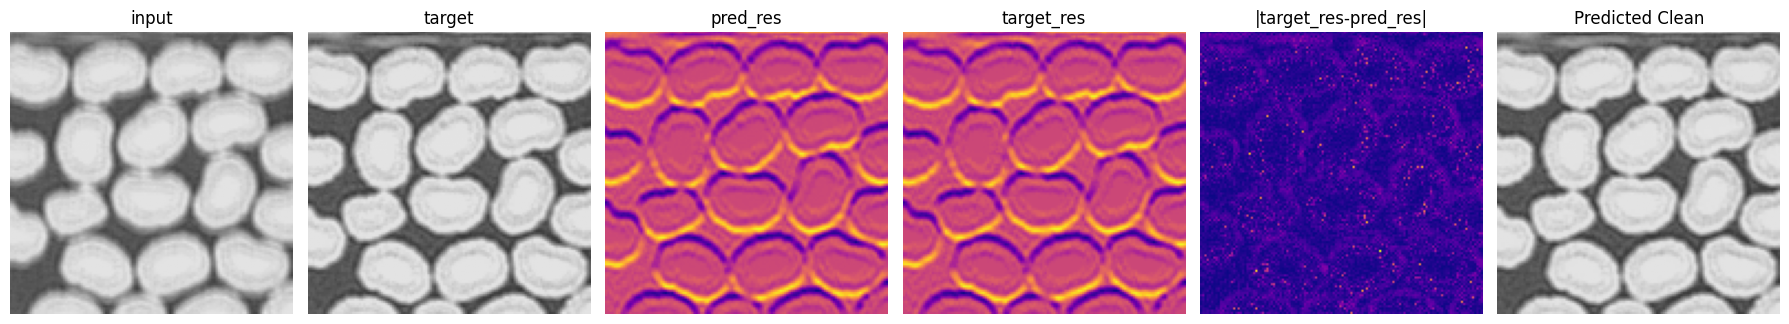

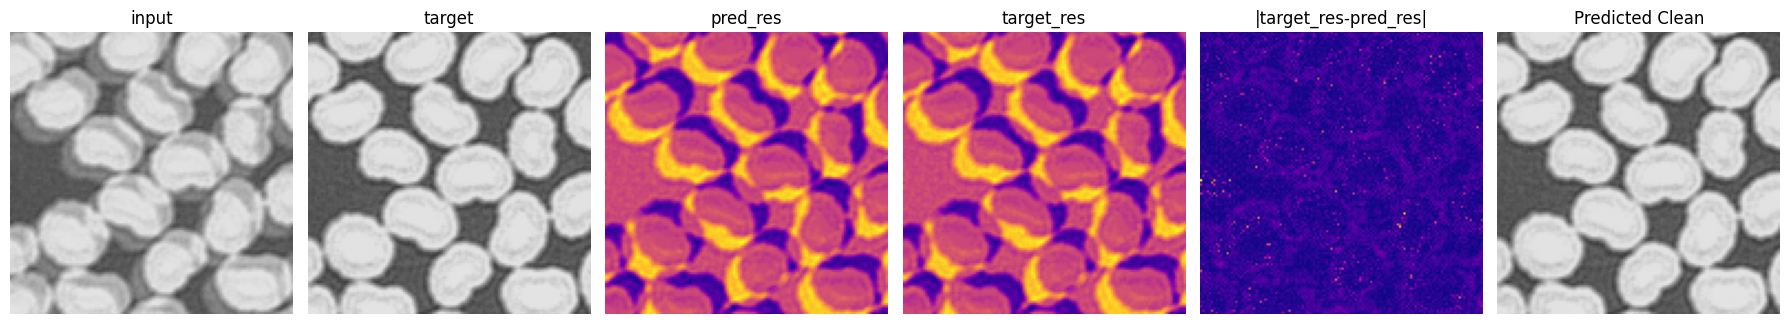

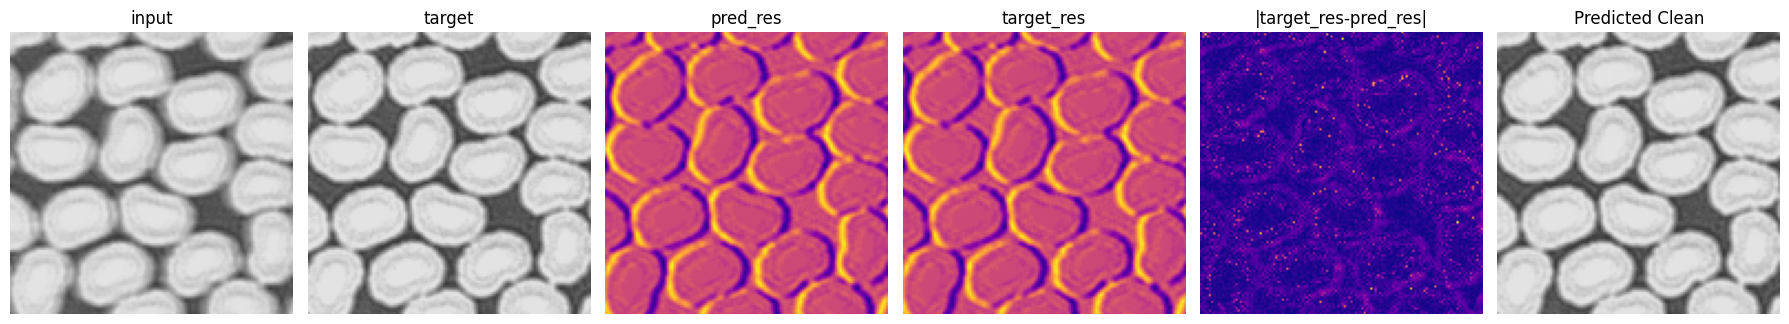

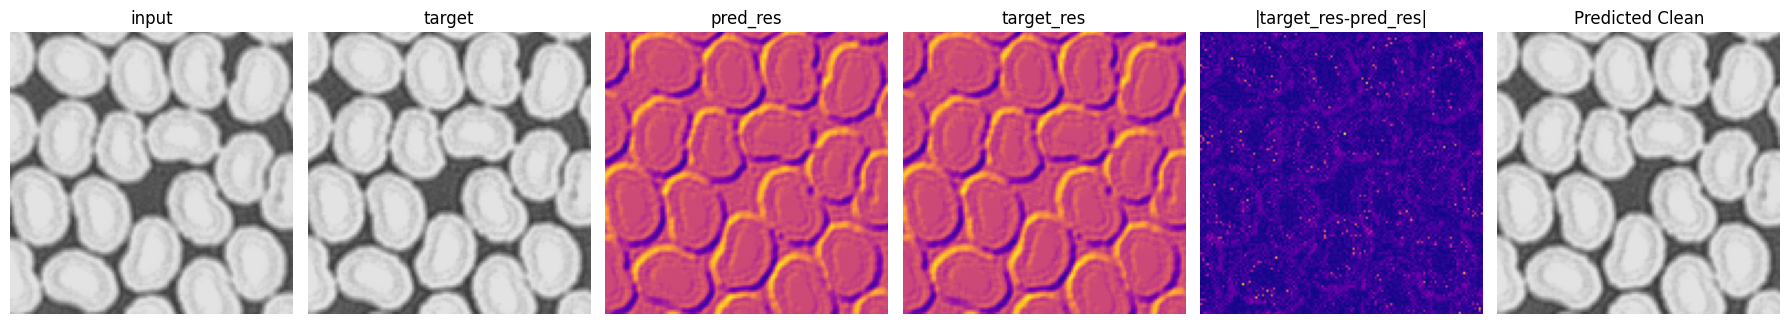

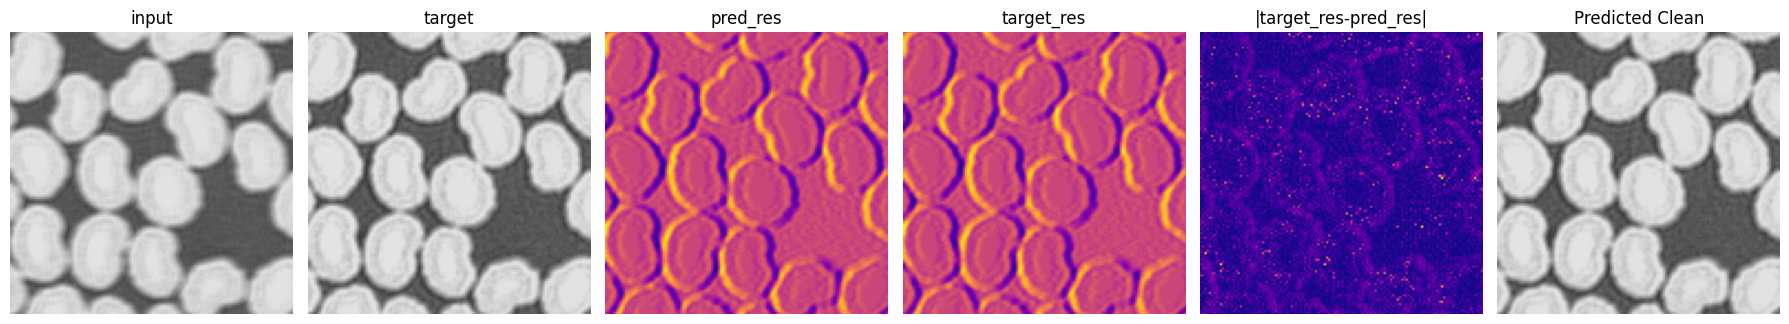

In [17]:
# --- Visual proof ---
bs = ghost.shape[0] # get batch size

for i in range(min(5,bs)):
    fig, axs = plt.subplots(1,6, figsize=(18,4))
    axs[0].imshow(ghost[i,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axs[0].set_title("input")

    axs[1].imshow(clean[i,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axs[1].set_title("target")

    axs[2].imshow(pred_res[i,0].cpu(), cmap="plasma")
    axs[2].set_title("pred_res")


    axs[3].imshow(target_res[i,0].cpu(), cmap="plasma")
    axs[3].set_title("target_res")

    axs[4].imshow((target_res-pred_res)[i,0].abs().cpu(), cmap="plasma")
    axs[4].set_title("|target_res-pred_res|")


    axs[5].imshow(pred_clean[i,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axs[5].set_title("Predicted Clean")

    for ax in axs:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Train Utils

In [11]:
from dataclasses import dataclass

import time

@dataclass
class TrainConfig:
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 1e-4
    amp: bool = True              # CUDA only
    grad_clip: float = 1.0        # 0 disables
    log_every: int = 50


@torch.no_grad()
def evaluate_residual(model, loader, device):
    model.eval()
    tot, tot_base, n = 0.0, 0.0, 0
    for ghost, clean, _meta in loader:
        ghost = ghost.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)

        target_res = clean - ghost
        pred_res = model(ghost)

        loss = F.l1_loss(pred_res, target_res)
        base = F.l1_loss(ghost, clean)  # identity baseline

        bs = ghost.size(0)
        tot += float(loss) * bs
        tot_base += float(base) * bs
        n += bs

    return tot / max(n, 1), tot_base / max(n, 1)


def train_deghost_residual(model, train_loader, val_loader, device, cfg: TrainConfig):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    use_amp = bool(cfg.amp and device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_baseline": [],
    }

    global_step = 0
    best_val = float("inf")
    best_state = None

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0 = time.time()
        running, seen = 0.0, 0

        for ghost, clean, _meta in train_loader:
            ghost = ghost.to(device, non_blocking=True)
            clean = clean.to(device, non_blocking=True)
            target_res = clean - ghost

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                pred_res = model(ghost)
                loss = F.l1_loss(pred_res, target_res)

            if use_amp:
                scaler.scale(loss).backward()
                if cfg.grad_clip and cfg.grad_clip > 0:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                if cfg.grad_clip and cfg.grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                opt.step()

            bs = ghost.size(0)
            running += float(loss.detach().item()) * bs
            seen += bs
            global_step += 1

            if cfg.log_every and (global_step % cfg.log_every == 0):
                print(f"epoch {epoch:03d} step {global_step:06d}  train_loss {running/max(seen,1):.5f}")

        train_loss = running / max(seen, 1)

        if val_loader is not None:
            val_loss, val_base = evaluate_residual(model, val_loader, device)
        else:
            val_loss, val_base = float("nan"), float("nan")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_baseline"].append(val_base)

        if val_loader is not None and val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        dt = time.time() - t0
        print(
            f"[epoch {epoch:03d}] "
            f"train {train_loss:.5f}  "
            f"val {val_loss:.5f}  "
            f"baseline {val_base:.5f}  "
            f"({dt:.1f}s)"
        )

    # restore best weights (optional but usually desirable)
    if best_state is not None:
        model.load_state_dict(best_state)

    return history


In [26]:
cfg = TrainConfig(
    epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    amp=True,
    grad_clip=1.0,
    log_every=50
)

model = DeGhostUNet(base=48).to(device).train()


history = train_deghost_residual(model, train_loader,val_loader, device, cfg)

# Optional: save model + history
torch.save({"model": model.state_dict(), "history": history}, "deghost_cnn.pt")
print("Saved checkpoint: deghost_cnn.pt")

[epoch 001] train 0.27771  val 0.08579  baseline 0.07657  (16.4s)
[epoch 002] train 0.08682  val 0.07695  baseline 0.07657  (16.1s)
epoch 003 step 000050  train_loss 0.09271
[epoch 003] train 0.09072  val 0.08857  baseline 0.07657  (15.1s)
[epoch 004] train 0.08515  val 0.07855  baseline 0.07657  (14.8s)
epoch 005 step 000100  train_loss 0.08431
[epoch 005] train 0.08437  val 0.07931  baseline 0.07657  (15.0s)
[epoch 006] train 0.08527  val 0.08187  baseline 0.07657  (15.2s)
epoch 007 step 000150  train_loss 0.08485
[epoch 007] train 0.08428  val 0.07825  baseline 0.07657  (15.4s)
[epoch 008] train 0.08247  val 0.07633  baseline 0.07657  (15.3s)
[epoch 009] train 0.08323  val 0.07651  baseline 0.07657  (15.1s)
epoch 010 step 000200  train_loss 0.09402
[epoch 010] train 0.08195  val 0.07581  baseline 0.07657  (15.2s)
[epoch 011] train 0.08173  val 0.07557  baseline 0.07657  (15.2s)
epoch 012 step 000250  train_loss 0.08176
[epoch 012] train 0.08070  val 0.07493  baseline 0.07657  (15.3s

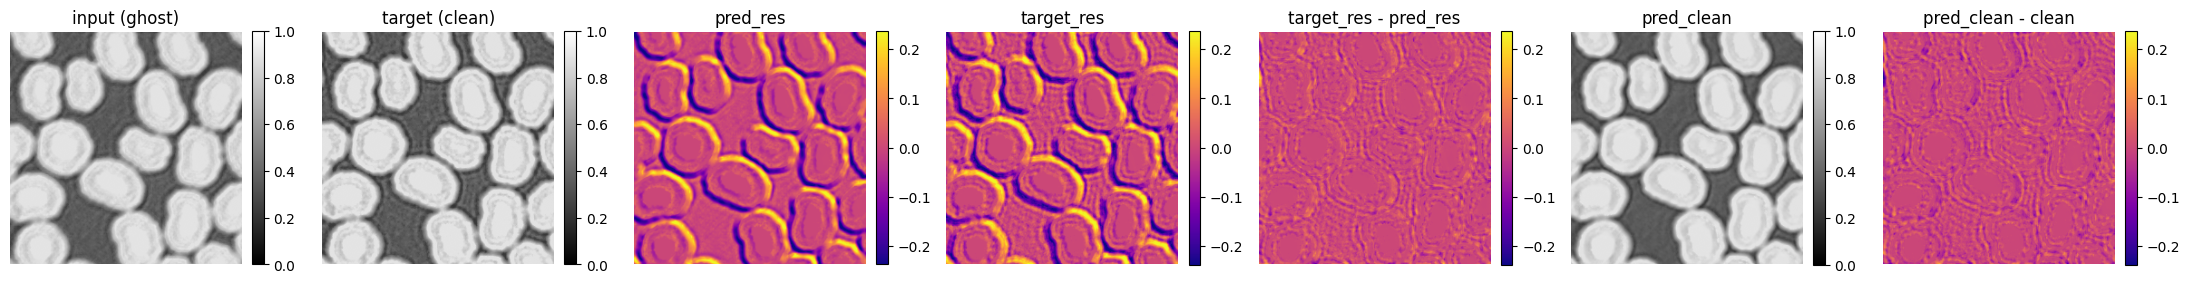

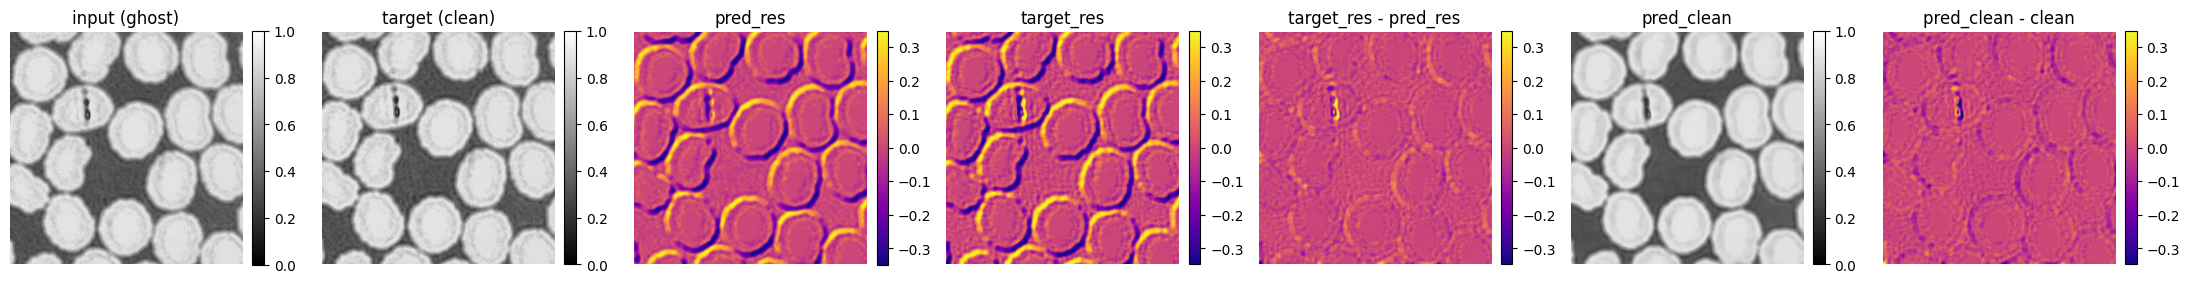

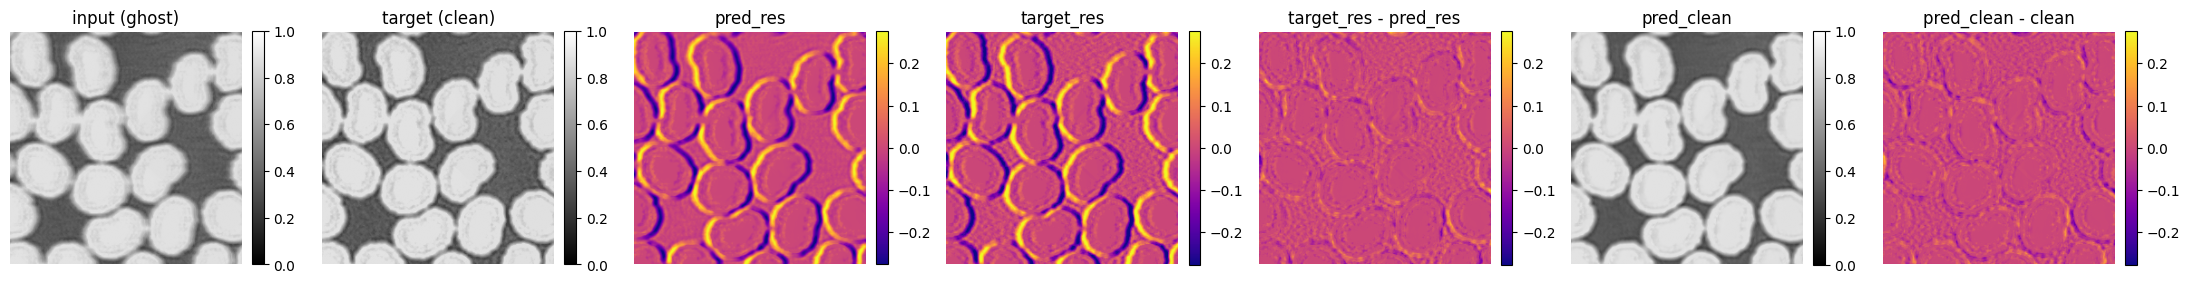

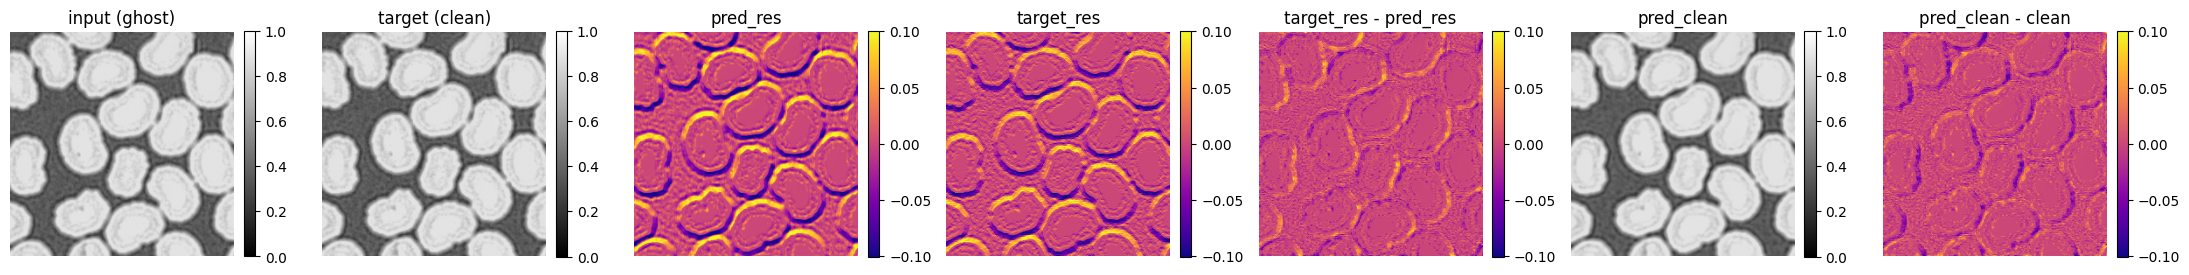

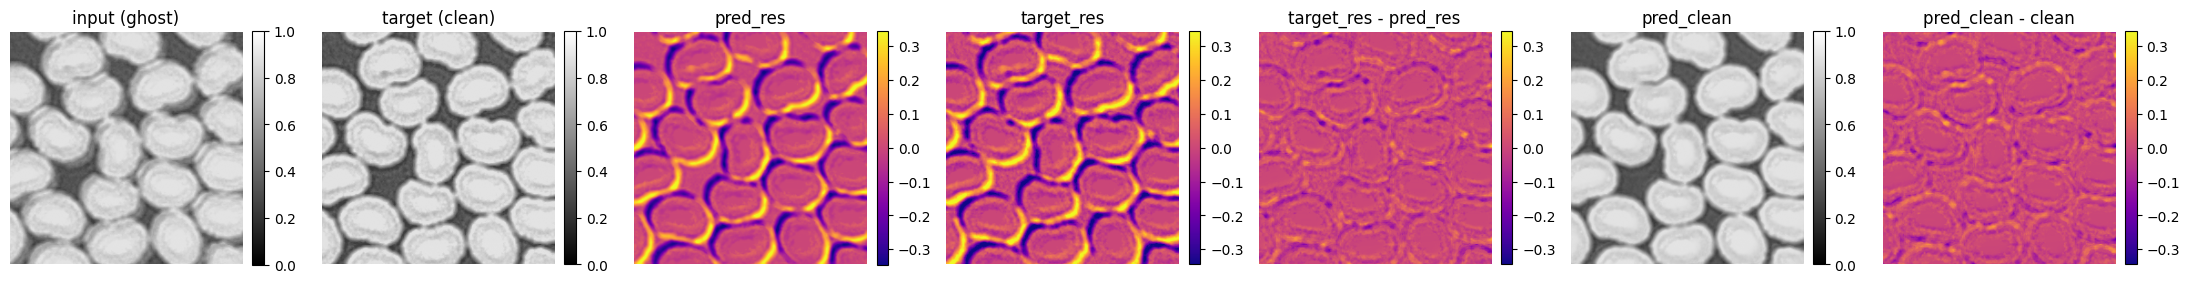

In [27]:
ghost, clean, _ = next(iter(val_loader))

# compute target residual on CPU (same batch)
target_res = clean - ghost

model.eval()
with torch.no_grad():
    ghost_d = ghost.to(device, non_blocking=True)
    pred_res = model(ghost_d)
    pred_clean = (ghost_d + pred_res).clamp(0, 1)

# bring preds back to CPU for plotting
pred_res = pred_res.cpu()
pred_clean = pred_clean.cpu()

bs = ghost.shape[0]

for i in range(min(5, bs)):
    fig, axs = plt.subplots(1, 7, figsize=(22, 4))

    # ---------- Input ----------
    im0 = axs[0].imshow(ghost[i, 0], cmap="gray", vmin=0, vmax=1)
    axs[0].set_title("input (ghost)")
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

    # ---------- Target ----------
    im1 = axs[1].imshow(clean[i, 0], cmap="gray", vmin=0, vmax=1)
    axs[1].set_title("target (clean)")
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    # ---------- Residual Scaling ----------
    # symmetric scaling for residual-like images
    res_stack = torch.stack([
        pred_res[i, 0],
        target_res[i, 0],
        (target_res - pred_res)[i, 0],
        (pred_clean - clean)[i, 0]
    ])
    vmax = torch.quantile(res_stack.abs(), 0.99).item()

    # ---------- Predicted Residual ----------
    im2 = axs[2].imshow(pred_res[i, 0], cmap="plasma", vmin=-vmax, vmax=vmax)
    axs[2].set_title("pred_res")
    fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

    # ---------- Target Residual ----------
    im3 = axs[3].imshow(target_res[i, 0], cmap="plasma", vmin=-vmax, vmax=vmax)
    axs[3].set_title("target_res")
    fig.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)

    # ---------- Residual Error ----------
    err_res = (target_res - pred_res)[i, 0]
    im4 = axs[4].imshow(err_res, cmap="plasma", vmin=-vmax, vmax=vmax)
    axs[4].set_title("target_res - pred_res")
    fig.colorbar(im4, ax=axs[4], fraction=0.046, pad=0.04)

    # ---------- Predicted Clean ----------
    im5 = axs[5].imshow(pred_clean[i, 0], cmap="gray", vmin=0, vmax=1)
    axs[5].set_title("pred_clean")
    fig.colorbar(im5, ax=axs[5], fraction=0.046, pad=0.04)

    # ---------- Signed Clean Error ----------
    diff = (pred_clean - clean)[i, 0]
    im6 = axs[6].imshow(diff, cmap="plasma", vmin=-vmax, vmax=vmax)
    axs[6].set_title("pred_clean - clean")
    fig.colorbar(im6, ax=axs[6], fraction=0.046, pad=0.04)

    for ax in axs:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [32]:
#load a test image with realistic shift
from PIL import Image


# --- Load image ---
image = Image.open("/content/drive/MyDrive/Colab Notebooks/DeGhosting/245_004.adj.test.tif").convert("L")

# --- Normalize to [0,1] float32 ---
image_np = np.array(image, dtype=np.float32) / 255.0

# --- Convert to tensor with shape (B, C, H, W) ---
image_tensor = torch.from_numpy(image_np).unsqueeze(0).unsqueeze(0)

# image_tensor = F.interpolate(image_tensor, scale_factor=0.5, mode="area")

print("Tensor shape:", image_tensor.shape)
print("dtype:", image_tensor.dtype)
print("min/max:", image_tensor.min().item(), image_tensor.max().item())

Tensor shape: torch.Size([1, 1, 256, 256])
dtype: torch.float32
min/max: 0.21176470816135406 0.8941176533699036


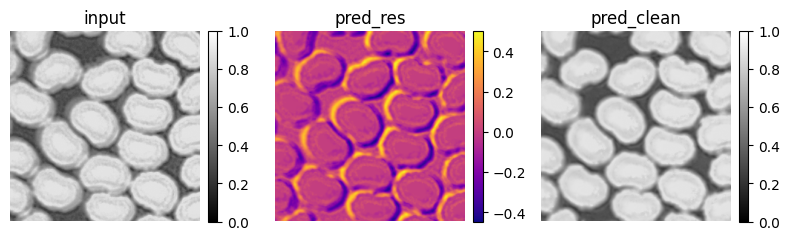

In [33]:
model.eval()
with torch.no_grad():
    ghost_d = image_tensor.to(device, non_blocking=True)
    pred_res = model(ghost_d)
    pred_clean = (ghost_d + pred_res).clamp(0, 1)

pred_clean_np = pred_clean.squeeze().squeeze().cpu().numpy()
pred_res_np = pred_res.squeeze().squeeze().cpu().numpy()

fig, axs = plt.subplots(1, 3, figsize=(8,4))


# --- Input ---
im0 = axs[0].imshow(image_np, cmap="gray", vmin=0, vmax=1)
axs[0].set_title("input")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# --- Residual ---
im1 = axs[1].imshow(pred_res_np, cmap="plasma")
axs[1].set_title("pred_res")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

# --- Clean ---
im2 = axs[2].imshow(pred_clean_np, cmap="gray", vmin=0, vmax=1)
axs[2].set_title("pred_clean")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()